In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ecommerce_customer_churn_dataset.csv')

print("Veri yüklendi!")
print(df.shape)
df.head()

Veri yüklendi!
(50000, 25)


,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [3]:
# Sütun isimlerini görelim
print(df.columns.tolist())

['Age', 'Gender', 'Country', 'City', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase', 'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate', 'Customer_Service_Calls', 'Product_Reviews_Written', 'Social_Media_Engagement_Score', 'Mobile_App_Usage', 'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance', 'Churned', 'Signup_Quarter']


In [4]:
# Veriye genel bakış
print("Churned müşteri oranı:")
print(df['Churned'].value_counts())
print(f"\nMüşteri kaybı oranı: %{df['Churned'].mean()*100:.1f}")

print("\nOrtalama sipariş değeri:")
print(f"Kalan müşteriler: {df[df['Churned']==0]['Average_Order_Value'].mean():.0f}")
print(f"Ayrılan müşteriler: {df[df['Churned']==1]['Average_Order_Value'].mean():.0f}")

Churned müşteri oranı:
Churned
0    35550
1    14450
Name: count, dtype: int64

Müşteri kaybı oranı: %28.9

Ortalama sipariş değeri:
Kalan müşteriler: 118
Ayrılan müşteriler: 135


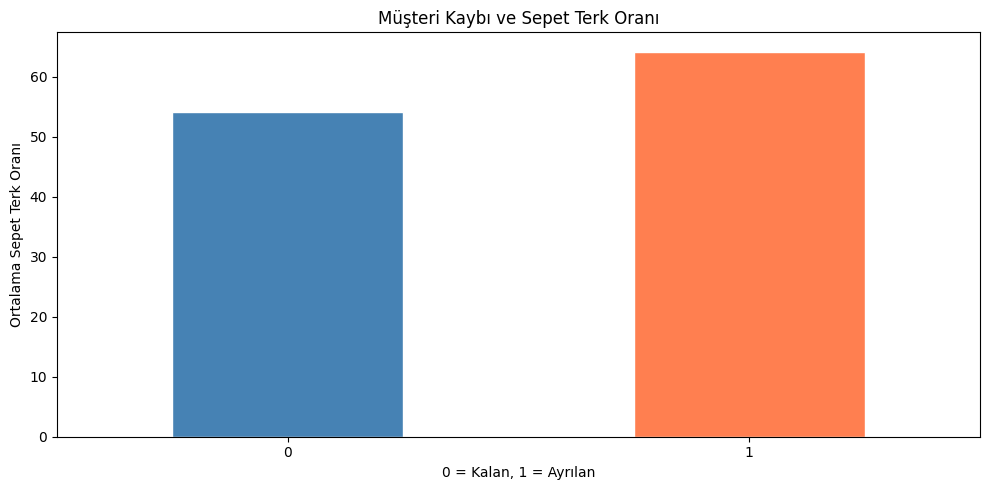

Churned
0    54.194460
1    64.178935
Name: Cart_Abandonment_Rate, dtype: float64


In [5]:
# Sepeti terk etme ve müşteri kaybı ilişkisi
plt.figure(figsize=(10,5))
df.groupby('Churned')['Cart_Abandonment_Rate'].mean().plot(
    kind='bar', color=['steelblue','coral'], edgecolor='white')
plt.title('Müşteri Kaybı ve Sepet Terk Oranı')
plt.xlabel('0 = Kalan, 1 = Ayrılan')
plt.ylabel('Ortalama Sepet Terk Oranı')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(df.groupby('Churned')['Cart_Abandonment_Rate'].mean())

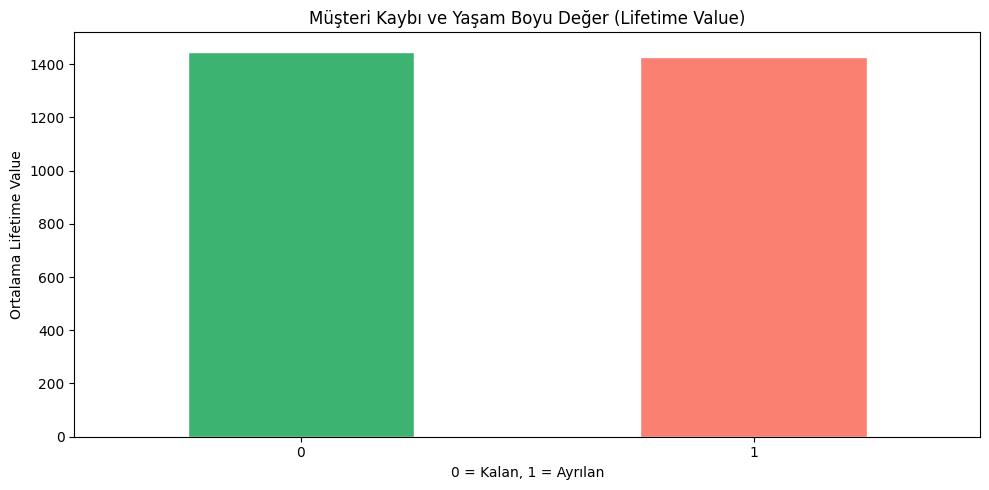

Churned
0    1446.805875
1    1425.423236
Name: Lifetime_Value, dtype: float64


In [6]:
# Lifetime Value ve müşteri kaybı
plt.figure(figsize=(10,5))
df.groupby('Churned')['Lifetime_Value'].mean().plot(
    kind='bar', color=['mediumseagreen','salmon'], edgecolor='white')
plt.title('Müşteri Kaybı ve Yaşam Boyu Değer (Lifetime Value)')
plt.xlabel('0 = Kalan, 1 = Ayrılan')
plt.ylabel('Ortalama Lifetime Value')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(df.groupby('Churned')['Lifetime_Value'].mean())

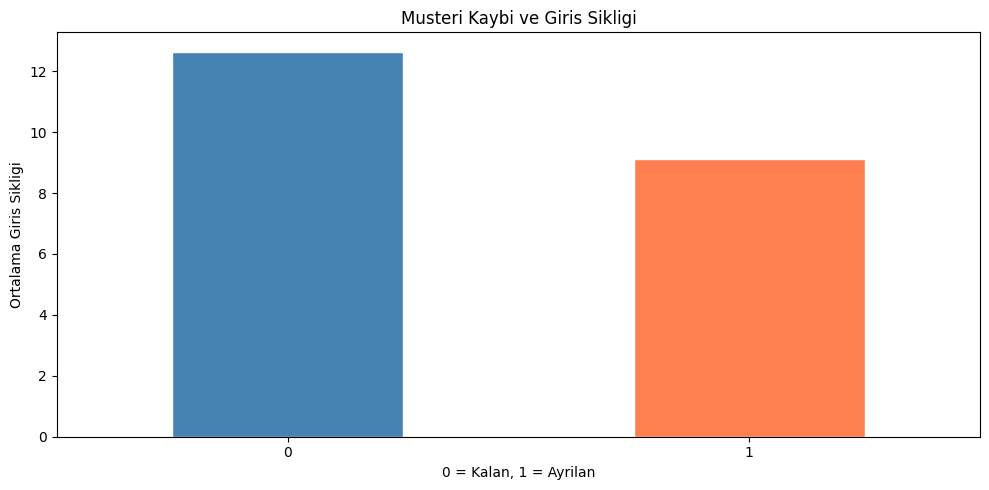

Churned
0    12.642391
1     9.120830
Name: Login_Frequency, dtype: float64


In [7]:
# Login sıklığı ve müşteri kaybı
plt.figure(figsize=(10,5))
df.groupby('Churned')['Login_Frequency'].mean().plot(
    kind='bar', color=['steelblue','coral'], edgecolor='white')
plt.title('Musteri Kaybi ve Giris Sikligi')
plt.xlabel('0 = Kalan, 1 = Ayrilan')
plt.ylabel('Ortalama Giris Sikligi')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(df.groupby('Churned')['Login_Frequency'].mean())

In [9]:
print("=" * 55)
print("E-TICARET MUSTERI KAYBI ANALIZI - OZET RAPOR")
print("=" * 55)

print(f"\nVERI: {len(df):,} musteri, {df.shape[1]} degisken")
print(f"Musteri kaybi orani: %{df['Churned'].mean()*100:.1f}")

print("\nANA BULGULAR:")
print("1. Ayrilan musteriler daha fazla harcıyor")
print(f"   Kalan: {df[df['Churned']==0]['Average_Order_Value'].mean():.0f} TL")
print(f"   Ayrilan: {df[df['Churned']==1]['Average_Order_Value'].mean():.0f} TL")

print("2. Sepet terk orani farki")
print(f"   Kalan: %{df[df['Churned']==0]['Cart_Abandonment_Rate'].mean():.1f}")
print(f"   Ayrilan: %{df[df['Churned']==1]['Cart_Abandonment_Rate'].mean():.1f}")

print("3. Login sikligi farki")
print(f"   Kalan: {df[df['Churned']==0]['Login_Frequency'].mean():.1f}x")
print(f"   Ayrilan: {df[df['Churned']==1]['Login_Frequency'].mean():.1f}x")

print("\nSTRATEJIK ONERILER:")
print("1. Login sikligi dusen musterilere bildirim gonder")
print("2. Yuksek sepet terk oranli musterilere indirim teklif et")
print("3. Yuksek harcayan ama ayrilan segmente VIP program olustur")

print("\n" + "=" * 55)
print("Analiz: Fatma Acar | Python & Pandas")
print("=" * 55)

E-TICARET MUSTERI KAYBI ANALIZI - OZET RAPOR

VERI: 50,000 musteri, 25 degisken
Musteri kaybi orani: %28.9

ANA BULGULAR:
1. Ayrilan musteriler daha fazla harcıyor
   Kalan: 118 TL
   Ayrilan: 135 TL
2. Sepet terk orani farki
   Kalan: %54.2
   Ayrilan: %64.2
3. Login sikligi farki
   Kalan: 12.6x
   Ayrilan: 9.1x

STRATEJIK ONERILER:
1. Login sikligi dusen musterilere bildirim gonder
2. Yuksek sepet terk oranli musterilere indirim teklif et
3. Yuksek harcayan ama ayrilan segmente VIP program olustur

Analiz: Fatma Acar | Python & Pandas
